In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip '/content/drive/MyDrive/experience 3.zip'

Streaming output truncated to the last 5000 lines.
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00033_Alf_Isolated_15.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00033_Alf_Isolated_6.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00033_Alf_Isolated_7.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00034_Alf_Isolated_14.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00034_Alf_Isolated_15.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00034_Alf_Isolated_6.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00034_Alf_Isolated_7.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00035_Alf_Isolated_14.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00035_Alf_Isolated_15.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00035_Alf_Isolated_6.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00035_Alf_Isolated_7.jpg  
  inflating: experience 3/Group k/Alf_Isolated/AHCR_00036_Alf_Isolated_14.j

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 150, 150
data_dir = "/content/experience 3"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2121/2121 ━━━━━━━━━━━━━━━━━━━━ 92s 39ms/step - accuracy: 0.2589 - loss: 2.0652 - val_accuracy: 0.5580 - val_loss: 1.2459
Epoch 2/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 76s 36ms/step - accuracy: 0.5292 - loss: 1.3253 - val_accuracy: 0.7097 - val_loss: 0.8485
Epoch 3/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 78s 37ms/step - accuracy: 0.6109 - loss: 1.1241 - val_accuracy: 0.7611 - val_loss: 0.6972
Epoch 4/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 81s 36ms/step - accuracy: 0.6536 - loss: 1.0122 - val_accuracy: 0.7725 - val_loss: 0.6662
Epoch 5/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 81s 36ms/step - accuracy: 0.6742 - loss: 0.9507 - val_accuracy: 0.7666 - val_loss: 0.7045
Epoch 6/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 77s 36ms/step - accuracy: 0.6903 - loss: 0.9016 - val_accuracy: 0.8077 - val_loss: 0.5857
Epoch 7/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.7059 - loss: 0.8577 - val_accuracy: 0.8162 - val_loss: 0.5462
Epoch 8/30
2121/2121 ━━━━━━━━━━━━━━━━━━━━ 75s 35ms/step - accuracy: 0.7185 - loss: 0.83

266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8719 - loss: 0.4051
Train Accuracy: 79.22%
Test Accuracy: 87.14%


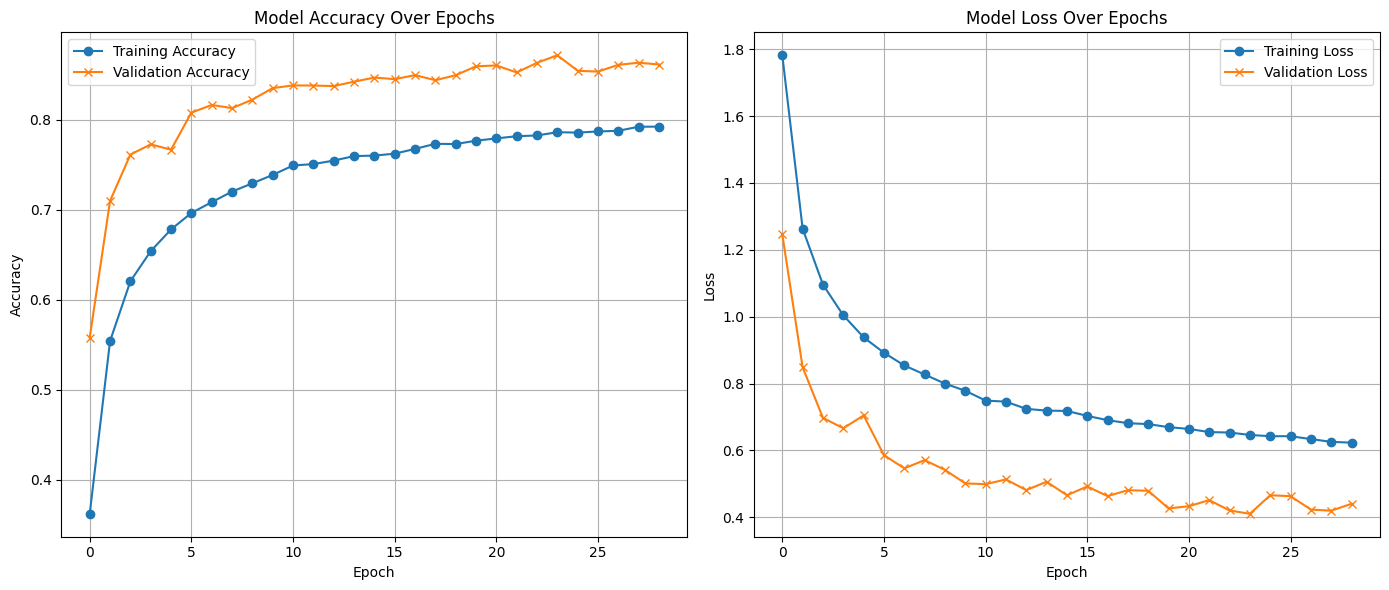

266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


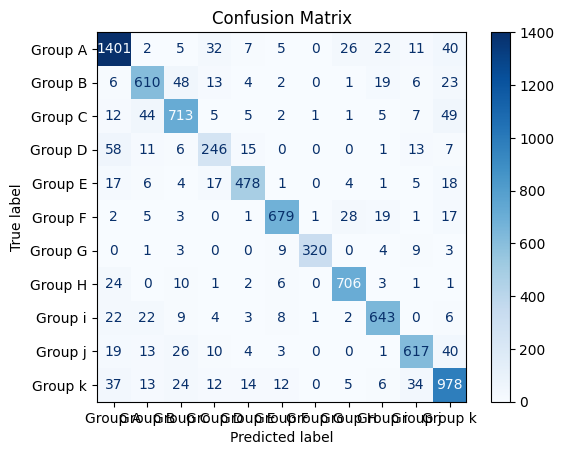

In [ ]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


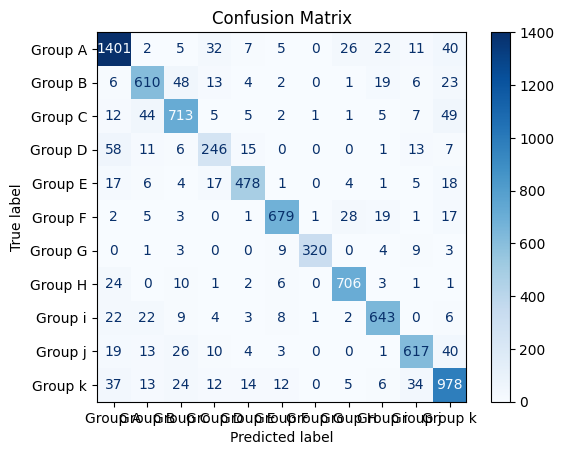

Number of incorrect predictions: 1091


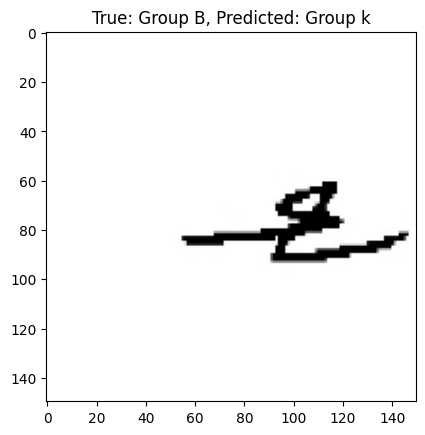

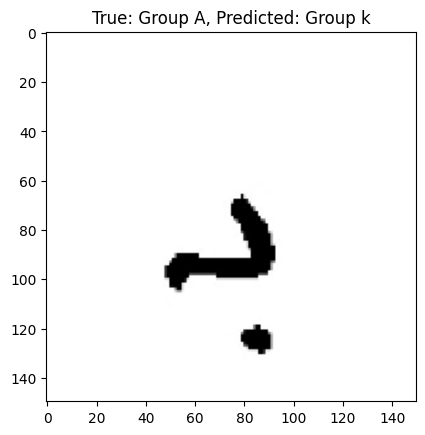

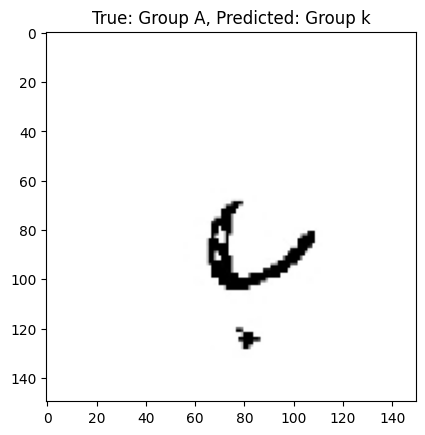

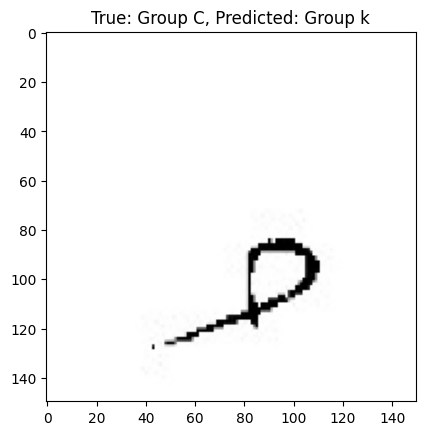

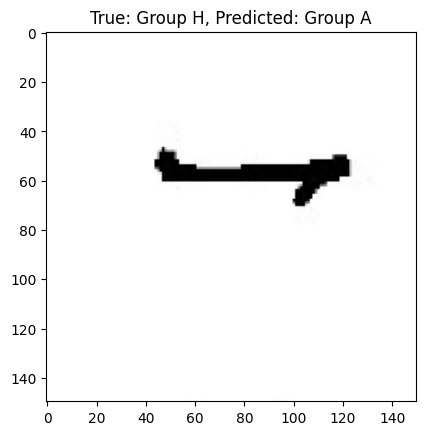

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(os.listdir(data_dir)))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


increase Batch size 


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 150, 150
data_dir = "/content/experience 3"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=25),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1357/1357 ━━━━━━━━━━━━━━━━━━━━ 76s 55ms/step - accuracy: 0.5126 - loss: 1.3797 - val_accuracy: 0.6685 - val_loss: 0.9591
Epoch 3/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 84s 57ms/step - accuracy: 0.5777 - loss: 1.1939 - val_accuracy: 0.7287 - val_loss: 0.8055
Epoch 4/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 80s 59ms/step - accuracy: 0.6487 - loss: 1.0149 - val_accuracy: 0.7607 - val_loss: 0.7086
Epoch 6/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 76s 56ms/step - accuracy: 0.6797 - loss: 0.9367 - val_accuracy: 0.7804 - val_loss: 0.6509
Epoch 7/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 73s 53ms/step - accuracy: 0.6888 - loss: 0.8975 - val_accuracy: 0.7705 - val_loss: 0.6868
Epoch 8/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 88s 58ms/step - accuracy: 0.7002 - loss: 0.8775 - val_accuracy: 0.8038 - val_loss: 0.5810
Epoch 9/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 85s 62ms/step - accuracy: 0.7091 - loss: 0.8645 - val_accuracy: 0.8193 - val_loss: 0.5462
Epoch 10/30
1357/1357 ━━━━━━━━━━━━━━━━━━━━ 156s 73ms/step - accuracy: 0.7245 - loss: 0.

266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8832 - loss: 0.3739
Train Accuracy: 80.05%
Test Accuracy: 87.92%


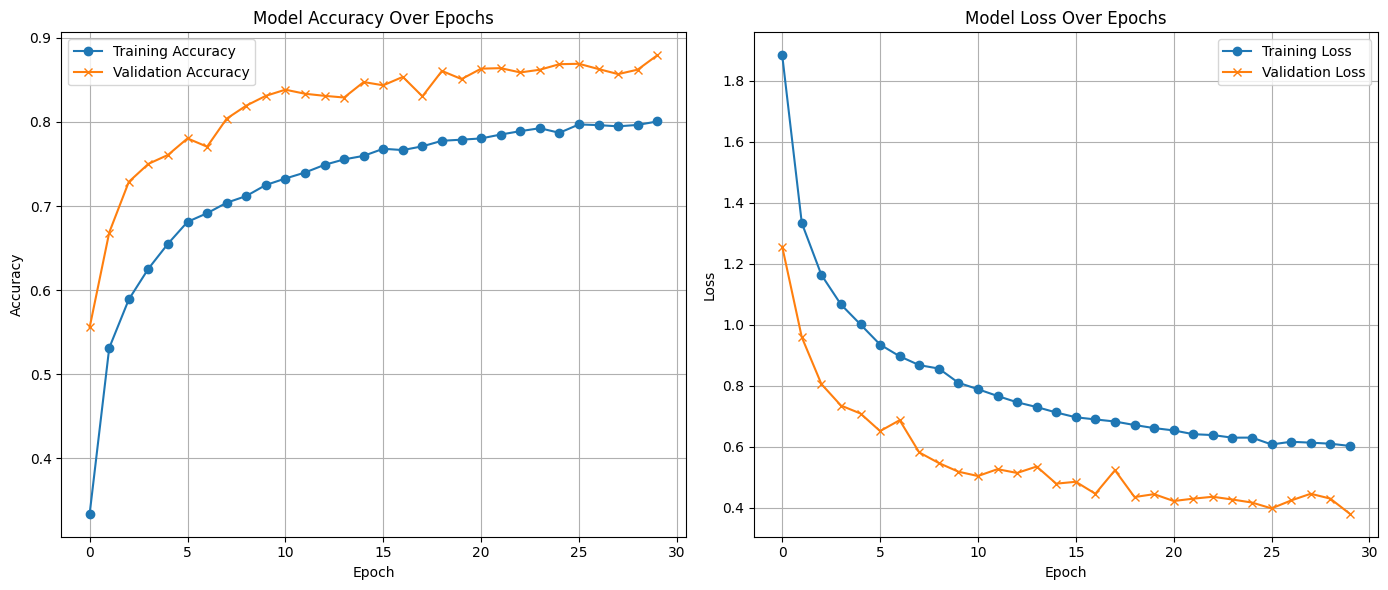

266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


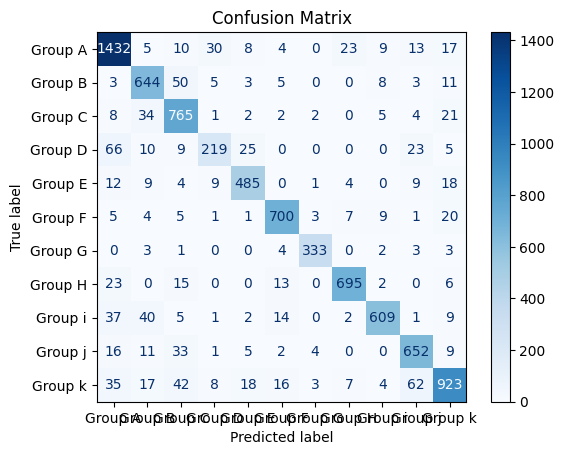

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Number of incorrect predictions: 1025


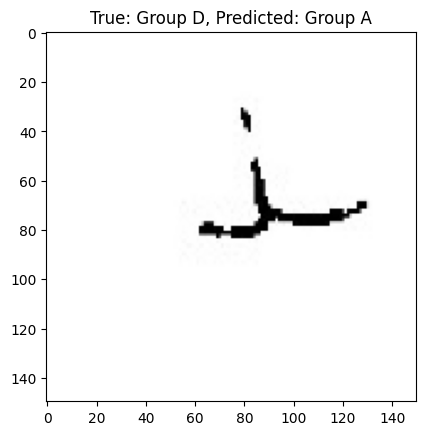

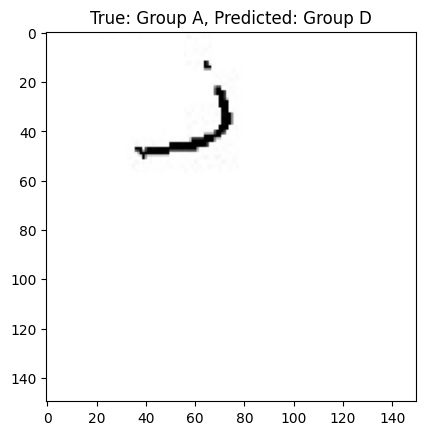

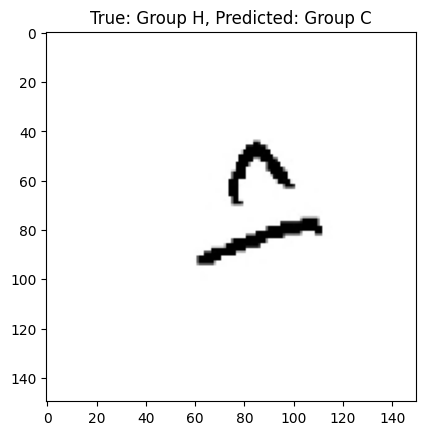

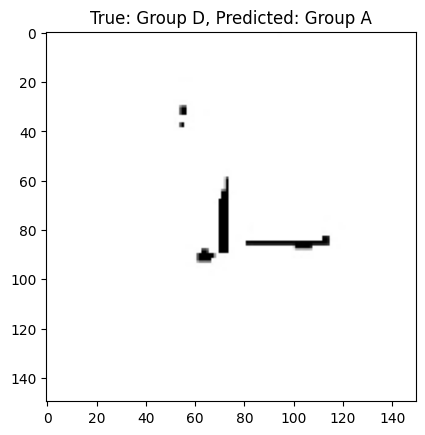

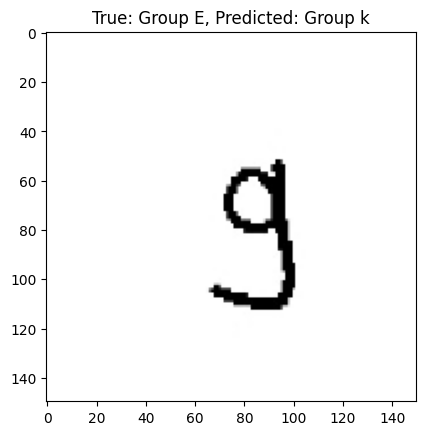

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


زيادة batchsize 25 to 32 and 
delete DropOut

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [10]:

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)



Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1061/1061 ━━━━━━━━━━━━━━━━━━━━ 84s 75ms/step - accuracy: 0.3273 - loss: 1.8891 - val_accuracy: 0.6116 - val_loss: 1.1321
Epoch 2/30
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 80s 74ms/step - accuracy: 0.6632 - loss: 0.9777 - val_accuracy: 0.7319 - val_loss: 0.7920
Epoch 3/30
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 80s 73ms/step - accuracy: 0.7285 - loss: 0.7878 - val_accuracy: 0.7727 - val_loss: 0.6670
Epoch 4/30
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.7615 - loss: 0.6938 - val_accuracy: 0.7912 - val_loss: 0.6278
Epoch 5/30
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.7902 - loss: 0.6219 - val_accuracy: 0.8263 - val_loss: 0.5139
Epoch 6/30
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 76s 72ms/step - accuracy: 0.7987 - loss: 0.5907 - val_accuracy: 0.8220 - val_loss: 0.5242
Epoch 7/30
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.8130 - loss: 0.5464 - val_accuracy: 0.8338 - val_loss: 0.4720
Epoch 8/30
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 140s 75ms/step - accuracy: 0.8140 - loss: 0.5

In [12]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8787 - loss: 0.3598
Train Accuracy: 87.39%
Test Accuracy: 87.64%


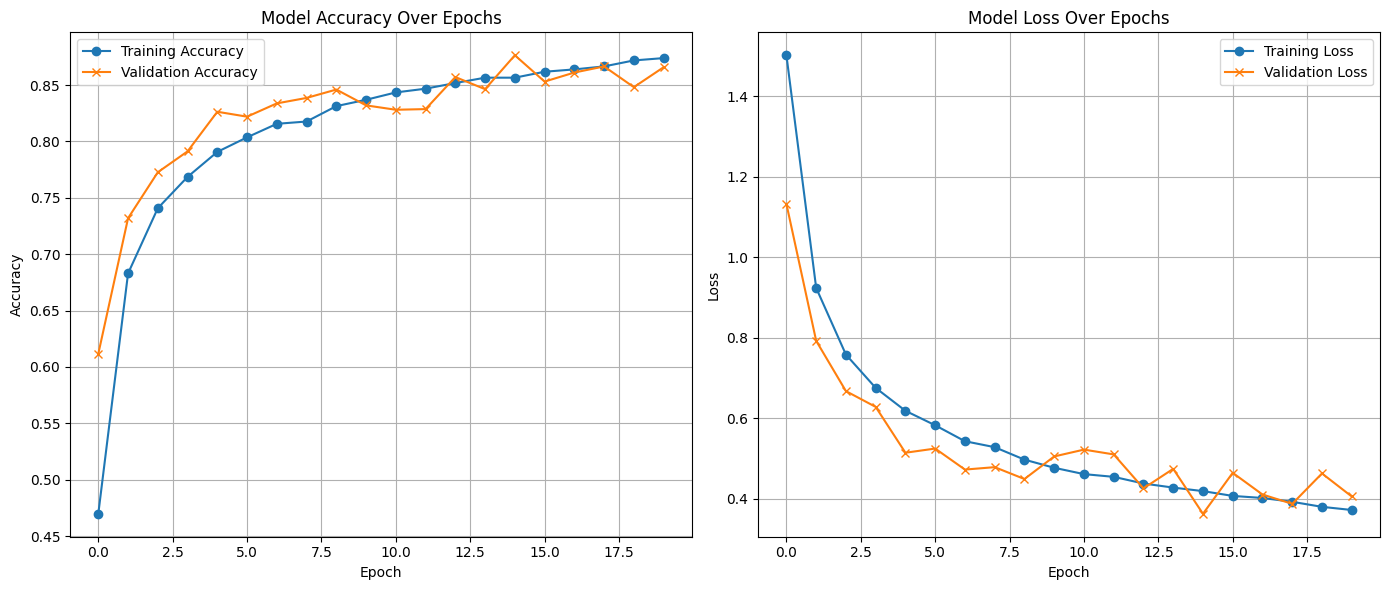

In [16]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


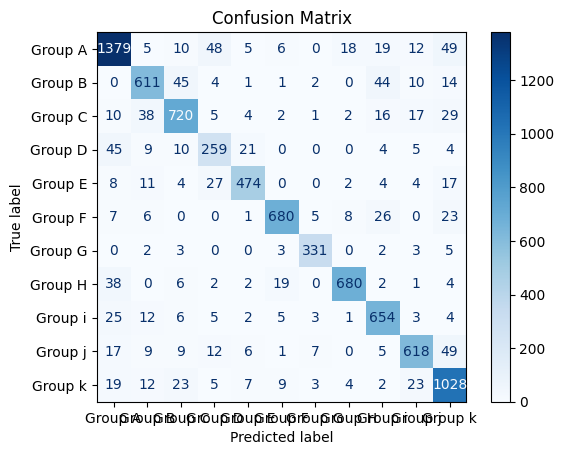

In [17]:

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Number of incorrect predictions: 1048


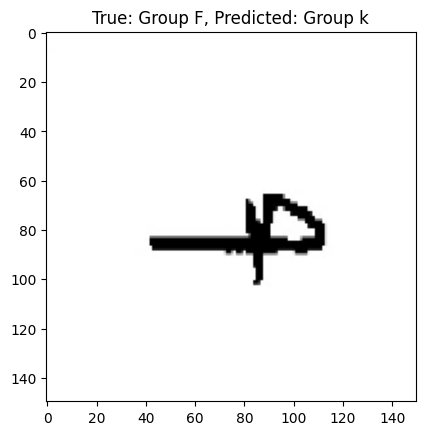

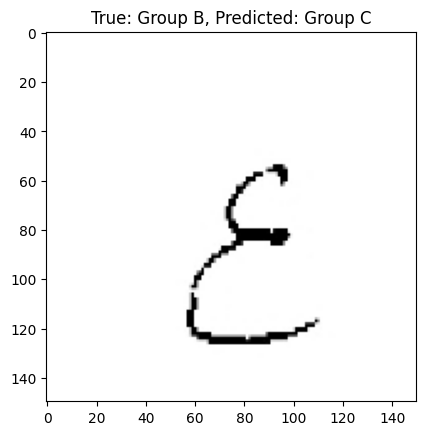

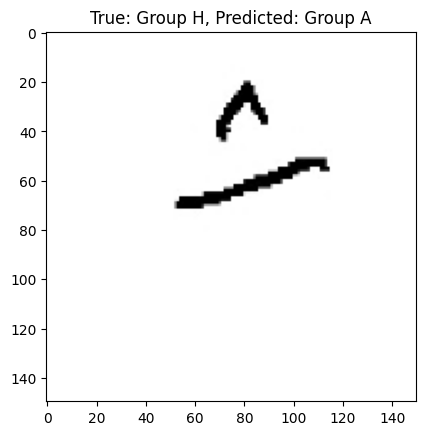

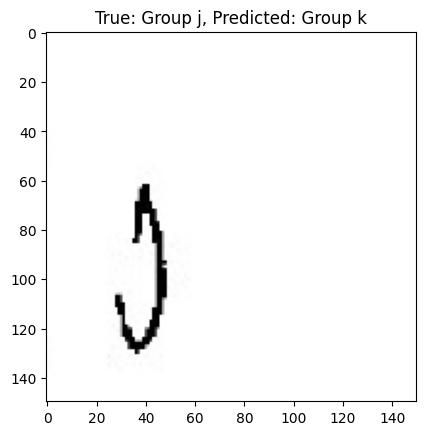

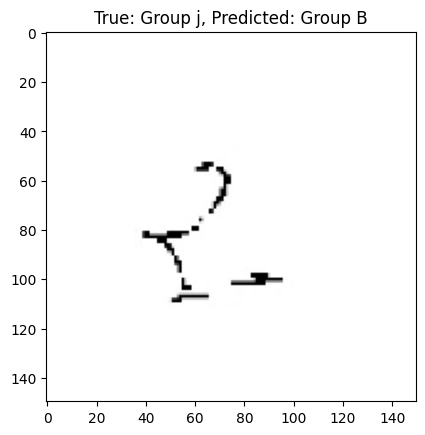

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

incorrect = np.where(y_pred != y_true)[0]
print(f"Number of incorrect predictions: {len(incorrect)}")

if len(incorrect) > 0:
    random_indices = np.random.choice(incorrect, size=min(5, len(incorrect)), replace=False)
    for idx in random_indices:
        plt.imshow(x_test[idx].reshape(150, 150), cmap='gray')
        plt.title(f"True: {sorted(os.listdir(data_dir))[y_true[idx]]}, Predicted: {sorted(os.listdir(data_dir))[y_pred[idx]]}")
        plt.show()
else:
    print("No incorrect predictions to display.")


In [18]:
model.save('cnn_model.keras')
